# Exercise 5
_Andreas Thöni_  
The own implementation of the FE-code has been moved to the folder "fe_ntnu" and is imported as a package. With nodal loads, hinges work now, but not with distributed loads.

In [1]:
from fe_ntnu import *
import numpy as np
import matplotlib.pyplot as plt

## Problem 1)
### a) Displacement in $z$

displacement in z at node 12: -0.01028438098121341


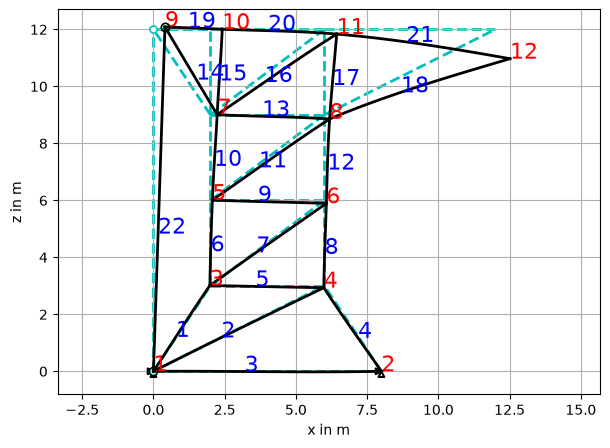

displacement vector r=
[ 0.00000000e+00  0.00000000e+00 -5.28302454e-05  0.00000000e+00
  0.00000000e+00 -1.90303414e-04 -1.91880191e-04  1.03570125e-04
  1.63951491e-04 -2.04347578e-04 -6.57031591e-04  1.31237526e-04
  6.75057330e-04  8.95501671e-05  3.86542374e-04  6.75052873e-04
 -1.05235498e-03  3.00366793e-04  2.36128839e-03  7.55268656e-05
  5.10478486e-04  1.82798203e-03 -1.44768082e-03  6.62842509e-04
  4.04921970e-03  8.37388404e-04  3.57486190e-04  4.14226237e-03
  7.55304717e-05  4.27814519e-04  4.32835434e-03 -1.64300282e-03
  8.45769551e-04  5.12832930e-03 -1.02843810e-02  1.75091268e-03]


In [9]:
E = 1e10 # Nm^2
I = 1e-6 # m^4
A = 0.3 # m^2
W = 200000 # N

n1 = Node(0,0, [0,1])
n2 = Node(8,0, [0,1])
n3 = Node(2,3)
n4 = Node(6,3)
n5 = Node(2,6)
n6 = Node(6,6)
n7 = Node(2,9)
n8 = Node(6,9)
n9 = Node(0,12)
n10 = Node(2,12)
n11 = Node(6,12)
n12 = Node(12, 12)

el1 = Element(n1, n3, E, 3*I, A)
el2 = Element(n1, n4, E, 3*I, A)
el3 = Element(n1, n2, E, 3*I, A)
el4 = Element(n2, n4, E, 3*I, A)
el5 = Element(n3, n4, E, 3*I, A)
el6 = Element(n3, n5, E, 3*I, A)
el7 = Element(n3, n6, E, 3*I, A)
el8 = Element(n4, n6, E, 3*I, A)
el9 = Element(n5, n6, E, 3*I, A)
el10 = Element(n5, n7, E, 3*I, A)
el11 = Element(n5, n8, E, 3*I, A)
el12 = Element(n6, n8, E, 3*I, A)
el13 = Element(n7, n8, E, 3*I, A)
el14 = Element(n7, n9, E, 3*I, A, hinge_n2=True)
el15 = Element(n7, n10, E, 3*I, A)
el16 = Element(n7, n11, E, 3*I, A)
el17 = Element(n8, n11, E, 3*I, A)
el18 = Element(n8, n12, E, 6*I, A)
el19 = Element(n9, n10, E, 3*I, A)
el20 = Element(n10, n11, E, 3*I, A)
el21 = Element(n11, n12, E, 6*I, A)
el22 = Element(n1, n9, E, I, A, hinge_n1=True, hinge_n2=True)

nl12 = NodalLoad(n12, Fx=0, Fz=-W, M=0)

orderednodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12]
elements = [el1, el2, el3, el4, el5, el6, el7, el8, el9, el10, el11, el12, el13, el14, el15, el16, el17, el18, el19, el20, el21, el22]
loads = [nl12]
sys = System(elements, loads=loads, nodes=orderednodes)

sys.assemble()
sys.apply_bcs()

r = sys.solve()
print(f'displacement in z at node 12: {r[11*3+1]}')
fig1 = plot_structure_def(sys, 100, supports=True)
print(f'displacement vector r=\n{r}')


### b) Reaction forces in A and B

In [3]:
R_force = sys.K_glob @ sys.r - sys.R_glob
#print(R_force)

Ah = R_force[0*3+0]
Av = R_force[0*3+1]
print(f'Reaction forces in A: A_h = {Ah}, A_v = {Av}')

Bh = R_force[1*3+0]
Bv = R_force[1*3+1]
print(f'Reaction forces in B: B_h = {Bh}, B_v = {Bv}')

diffx = Ah + Bh
diffz = Av + Bv -W

print(f'resultant force in x: {diffx}')
print(f'resultant force in z: {diffz}')

Reaction forces in A: A_h = 199996.5051020236, A_v = -100000.00000000413
Reaction forces in B: B_h = -199996.50510202648, B_v = 300000.0000000045
resultant force in x: -2.8812792152166367e-09
resultant force in z: 3.4924596548080444e-10


The equilibrium condition is fulfilled down to machine precision.

### c) Internal forces in beam AC

Normal force: 209347.10111727891
Shear force: -0.0
Bending moment: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


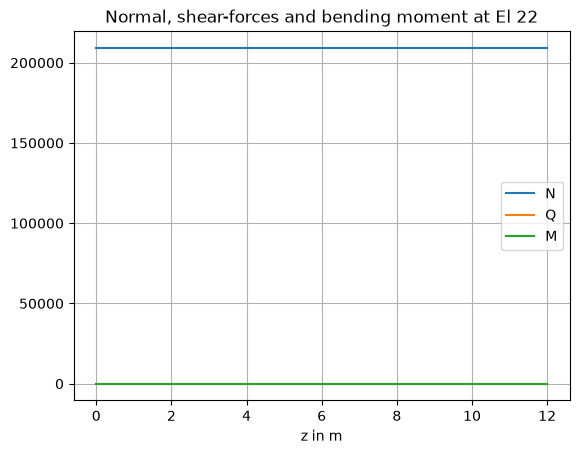

In [6]:
x = np.linspace(0,12,13)

r_el22 = sys.r[el22.n1.dofs + el22.n2.dofs] # displacement vec

S_loc22 = el22.get_k_local() @ el22.Tg @ r_el22 # tf r to local transform
N = -S_loc22[0]
Q = -S_loc22[1]
M = -Q*x
print(f'Normal force: {N}\nShear force: {Q}\nBending moment: {M}')

plt.plot(x, np.ones_like(x)*N, label="N")
plt.plot(x, np.ones_like(x)*Q, label="Q")
plt.plot(x,M, label="M")
plt.legend()
plt.grid()
plt.title('Normal, shear-forces and bending moment at El 22')
plt.xlabel('z in m')
plt.ylabel('')
plt.show()

It is visible that the bending moment and the shear forces are zero and only normal forces are existent.

## Problem 2)
plotting the calculated polynomials to make sure they satisfy the conditions $N_i(x=x_i)=1$ and $N_i(x=x_j)=0$.

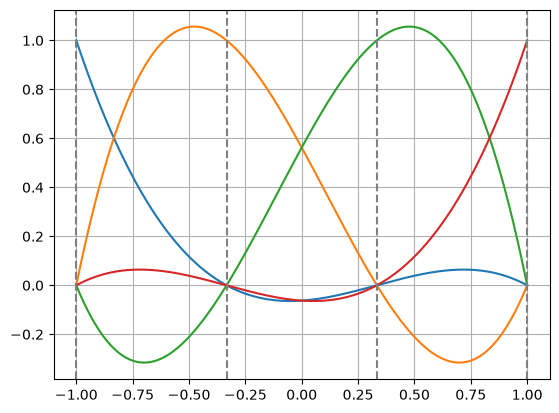

In [5]:
zetas = np.array([-1, -1/3, 1/3, 1])
zeta = np.linspace(-1, 1, 2001)#

N1 = -9/16 * (zeta+1/3)*(zeta-1/3)*(zeta-1)
N2 = 27/16 * (zeta+1)*(zeta-1/3)*(zeta-1)
N3 = -27/16 * (zeta+1)*(zeta+1/3)*(zeta-1)
N4 = 9/16 * (zeta+1)*(zeta+1/3)*(zeta-1/3)

plt.plot(zeta, N1)
plt.plot(zeta, N2)
plt.plot(zeta, N3)
plt.plot(zeta, N4)

for i in zetas:
    plt.axvline(i, linestyle='--', color='grey')

plt.grid()

It is apparent that the calculated polynomials satisfy the conditions specified above.